**NAME   :** SASI KUMAR B

**REG NO  :** 212223060252

**EXP NO  :** 5

**EXP NAME:** PSK & QPSK

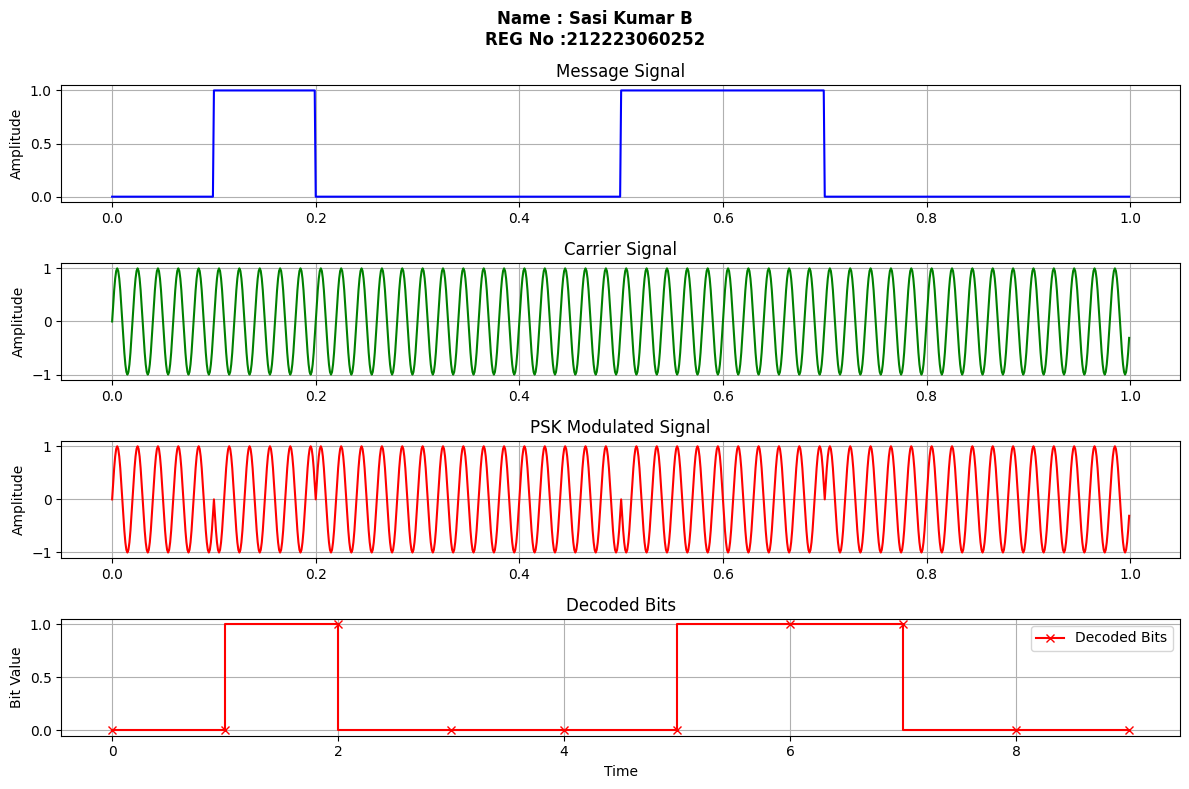

In [2]:
#PSK

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, lfilter
# Butterworth low-pass filter for demodulation
def butter_lowpass_filter(data, cutoff, fs, order=5):
    nyquist = 0.5 * fs
    normal_cutoff = cutoff / nyquist
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    return lfilter(b, a, data)
# Parameters
fs = 1000                # Sampling frequency
f_carrier = 50           # Carrier frequency
bit_rate = 10            # Data rate (bits per second)
T = 1                    # Total time duration in seconds
t = np.linspace(0, T, int(fs * T), endpoint=False)
# Message signal (binary data)
bits = np.random.randint(0, 2, bit_rate)
bit_duration = fs // bit_rate
message_signal = np.repeat(bits, bit_duration)
# PSK Modulation (0 -> 0 phase, 1 -> 180° phase shift)
carrier = np.sin(2 * np.pi * f_carrier * t)
psk_signal = np.sin(2 * np.pi * f_carrier * t + np.pi * message_signal)
# PSK Demodulation
demodulated = psk_signal * carrier
filtered_signal = butter_lowpass_filter(demodulated, f_carrier, fs)
decoded_bits = (filtered_signal[::bit_duration] < 0).astype(int)
# Plotting
plt.figure(figsize=(12, 8))
plt.subplot(4, 1, 1)
plt.suptitle("Name : Sasi Kumar B\nREG No :212223060252", fontsize=12, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.88])
plt.plot(t, message_signal, label='Message Signal (Binary)', color='b')
plt.title('Message Signal')
plt.ylabel('Amplitude')
plt.grid(True)
plt.subplot(4, 1, 2)
plt.plot(t, carrier, label='Carrier Signal', color='g')
plt.title('Carrier Signal')
plt.ylabel('Amplitude')
plt.grid(True)
plt.subplot(4, 1, 3)
plt.plot(t, psk_signal, label='PSK Modulated Signal', color='r')
plt.title('PSK Modulated Signal')
plt.ylabel('Amplitude')
plt.grid(True)
plt.subplot(4, 1, 4)
plt.step(np.arange(len(decoded_bits)), decoded_bits, label='Decoded Bits', color='r', marker='x')
plt.title('Decoded Bits')
plt.xlabel('Time')
plt.ylabel('Bit Value')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

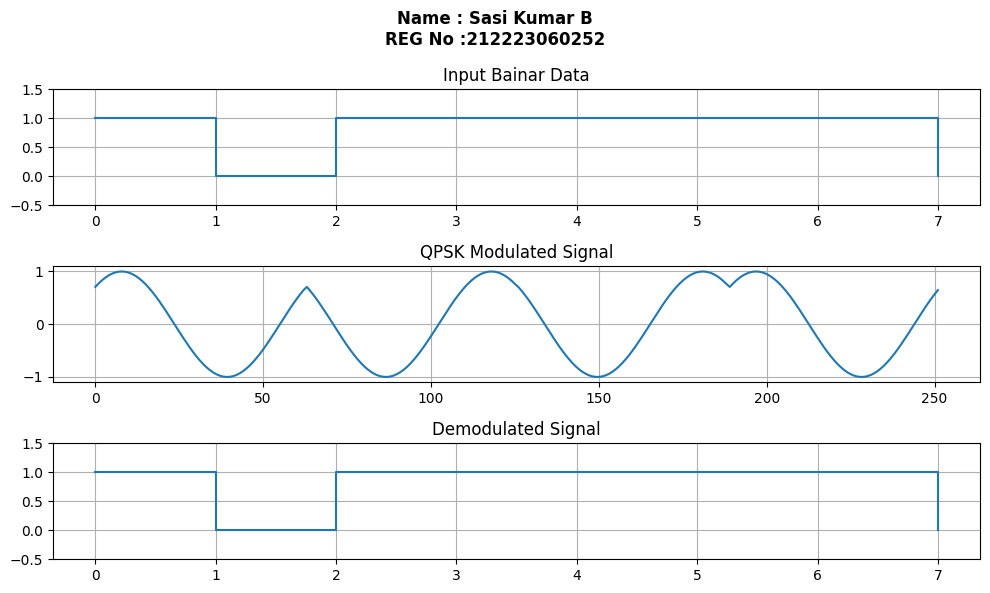

In [1]:
#QPSK
import numpy as np
import matplotlib.pyplot as plt

# Define input symbols (bit pairs)
x = ['10', '11', '11', '10']
n = len(x)
t = np.arange(-np.pi, np.pi, 0.1)

# Define phase shifted sine waves for each QPSK symbol
a = np.sin(t + (np.pi / 4))       # 00
b = np.sin(t + (3 * np.pi / 4))   # 01
c = np.sin(t + (5 * np.pi / 4))   # 10
d = np.sin(t + (7 * np.pi / 4))   # 11

# Modulate signal
mod = []
inp = []

for i in range(n):
    if x[i] == '00':
        mod.extend(a)
        inp.extend([0, 0])
    elif x[i] == '01':
        mod.extend(b)
        inp.extend([0, 1])
    elif x[i] == '10':
        mod.extend(c)
        inp.extend([1, 0])
    elif x[i] == '11':
        mod.extend(d)
        inp.extend([1, 1])

# Time base for square waves
bit_duration = len(t)
inp_time = np.repeat(np.arange(len(inp)), 2)
inp_wave = np.repeat(inp, 2)

# Demodulation
demod = []
ptr = 2  # sampling point

for i in range(n):
    val = mod[i * len(t) + ptr]
    if val <= -0.77:
        demod.extend([0, 0])
    elif -0.77 < val <= -0.63:
        demod.extend([0, 1])
    elif val >= 0.77:
        demod.extend([1, 0])
    else:
        demod.extend([1, 1])

demod_time = np.repeat(np.arange(len(demod)), 2)
demod_wave = np.repeat(demod, 2)

# Plotting
plt.figure(figsize=(10, 6))

plt.subplot(3, 1, 1)
plt.plot(inp_time, inp_wave, drawstyle='steps-post')
plt.suptitle("Name : Sasi Kumar B\nREG No :212223060252", fontsize=12, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.88])
plt.title('Input Bainar Data')
plt.ylim(-0.5, 1.5)
plt.grid(True)

plt.subplot(3, 1, 2)
plt.plot(mod)
plt.grid(True)
plt.title('QPSK Modulated Signal')

plt.subplot(3, 1, 3)
plt.plot(demod_time, demod_wave, drawstyle='steps-post')
plt.title('Demodulated Signal')
plt.ylim(-0.5, 1.5)
plt.tight_layout()
plt.grid(True)
plt.show()